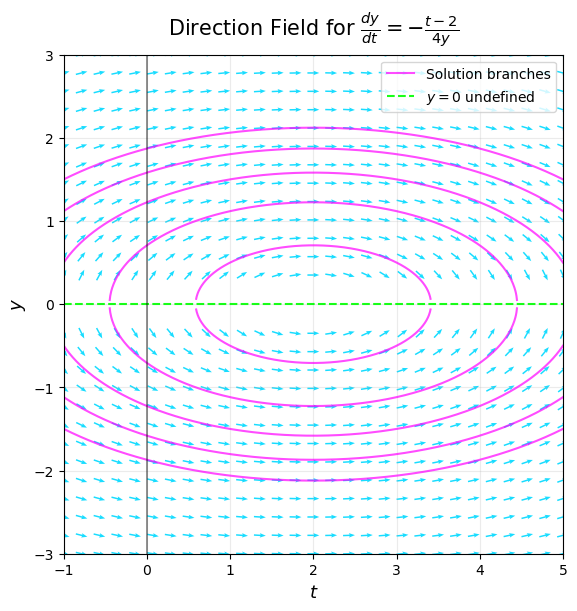

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Direction field for dy/dt = -(t - 2)/4y
# ---------------------------------------------------

# Grid
t = np.linspace(-1, 5, 29)

# Avoid y = 0 because the differential equation is undefined there
y_positive = np.linspace(0.35, 3, 13)
y_negative = np.linspace(-3, -0.35, 13)
y = np.concatenate([y_negative, y_positive])

T, Y = np.meshgrid(t, y)

# Differential equation
M = -(T - 2) / (4 * Y)

# Use true data-coordinate normalization
L = np.sqrt(1 + M**2)

U = 1 / L
V = M / L

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6),
    constrained_layout=True
)

# ---------------------------------------------------
# Direction field
# ---------------------------------------------------

ax.quiver(
    T, Y,
    U, V,
    color='#00d9ff',
    angles='xy',
    scale_units='xy',
    scale=7,
    width=0.003,
    pivot='middle',
    headwidth=3,
    headlength=4,
    headaxislength=3.5,
    alpha=0.9
)

# ---------------------------------------------------
# Implicit solution branches
#
# 2y^2 = -t^2/2 + 2t + c
#
# Equivalently:
#
# y^2 = t - t^2/4 + c/2
# ---------------------------------------------------

t_curve = np.linspace(-1, 5, 1000)

constants = [-1, 1, 3, 5, 7]

for i, c in enumerate(constants):

    inside = t_curve - (t_curve**2) / 4 + c / 2

    # Only plot where the square root is real
    mask = inside >= 0

    y_upper = np.sqrt(inside[mask])
    y_lower = -np.sqrt(inside[mask])

    ax.plot(
        t_curve[mask],
        y_upper,
        color='magenta',
        linewidth=1.5,
        alpha=0.7,
        label="Solution branches" if i == 0 else None
    )

    ax.plot(
        t_curve[mask],
        y_lower,
        color='magenta',
        linewidth=1.5,
        alpha=0.7
    )

# ---------------------------------------------------
# Singular line y = 0
# ---------------------------------------------------

ax.axhline(
    0,
    color='lime',
    linewidth=1.5,
    linestyle='--',
    alpha=0.9,
    label=r"$y=0$ undefined"
)

# ---------------------------------------------------
# Axes
# ---------------------------------------------------

ax.axvline(
    0,
    color='black',
    linewidth=1.1,
    alpha=0.55
)

# ---------------------------------------------------
# Labels and title
# ---------------------------------------------------

ax.set_xlabel(r"$t$", fontsize=13)
ax.set_ylabel(r"$y$", fontsize=13)

ax.set_title(
    r"Direction Field for $ \frac{dy}{dt} = -\frac{t-2}{4y} $",
    fontsize=15,
    pad=14
)

# ---------------------------------------------------
# Limits
# ---------------------------------------------------

ax.set_xlim(-1, 5)
ax.set_ylim(-3, 3)

# Preserve true geometric slope directions
ax.set_aspect('equal', adjustable='box')

# ---------------------------------------------------
# Grid
# ---------------------------------------------------

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.8
)

# ---------------------------------------------------
# Legend
# ---------------------------------------------------

ax.legend(
    fontsize=10,
    loc='upper right'
)

plt.show()